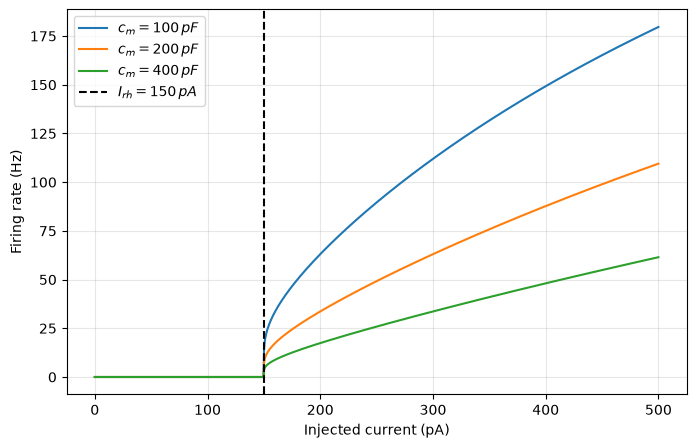

In [86]:
import numpy as np
import matplotlib.pyplot as plt 


def analytical_firing_rate(
    i,
    t_refractory,
    v_threshold,
    v_reset,
    e_l,
    r_m,
    c_m
):
    I_rh = (v_threshold - e_l)/r_m
    tau = r_m * c_m

    F = np.zeros_like(i)

    above_rheobase = i > I_rh
    v_inf = r_m * i[above_rheobase] + e_l

    T = tau * np.log((v_reset - v_inf)/(v_threshold - v_inf))

    F[above_rheobase] = 1 / (t_refractory + T)

    return F, I_rh



capacitances = np.array([100 , 200, 400]) * 1e-12
i = np.linspace(0, 500, 1000) * 1e-12

plt.figure(figsize=(8, 5))
for c_m in capacitances:
    frequency, I_rh = analytical_firing_rate(
        i = i,
        t_refractory = 2 * 1e-3,
        v_threshold = -50e-3, 
        v_reset = -65e-3, 
        e_l = -65e-3, 
        r_m = 100e6, 
        c_m = c_m
        )
    
    plt.plot(i * 1e12, frequency, label = fr'$c_{{m}} = {c_m * 1e12:.0f}\, {{pF}} $')


plt.axvline(
    I_rh * 1e12,
    color='black',
    linestyle='--',
    label = fr'$I_{{rh}} = {I_rh * 1e12:.0f} \, {{pA}}$'
)

plt.xlabel('Injected current (pA)')
plt.ylabel('Firing rate (Hz)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()






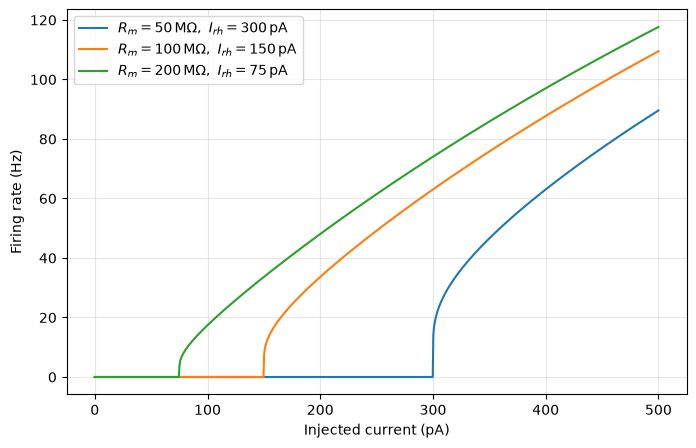

In [87]:
resistances = np.array([50, 100, 200]) * 1e6
i = np.linspace(0, 500, 1000) * 1e-12

plt.figure(figsize=(8, 5))
for r_m in resistances:
    frequency, I_rh = analytical_firing_rate(
        i = i,
        t_refractory = 2 * 1e-3,
        v_threshold = -50e-3, 
        v_reset = -65e-3, 
        e_l = -65e-3, 
        r_m = r_m, 
        c_m = 200 * 1e-12
        )
    
    plt.plot(i * 1e12, frequency, label=fr'$R_m={r_m / 1e6:.0f}\,\mathrm{{M\Omega}},\ I_{{rh}}={I_rh * 1e12:.0f}\,\mathrm{{pA}}$')


plt.xlabel('Injected current (pA)')
plt.ylabel('Firing rate (Hz)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

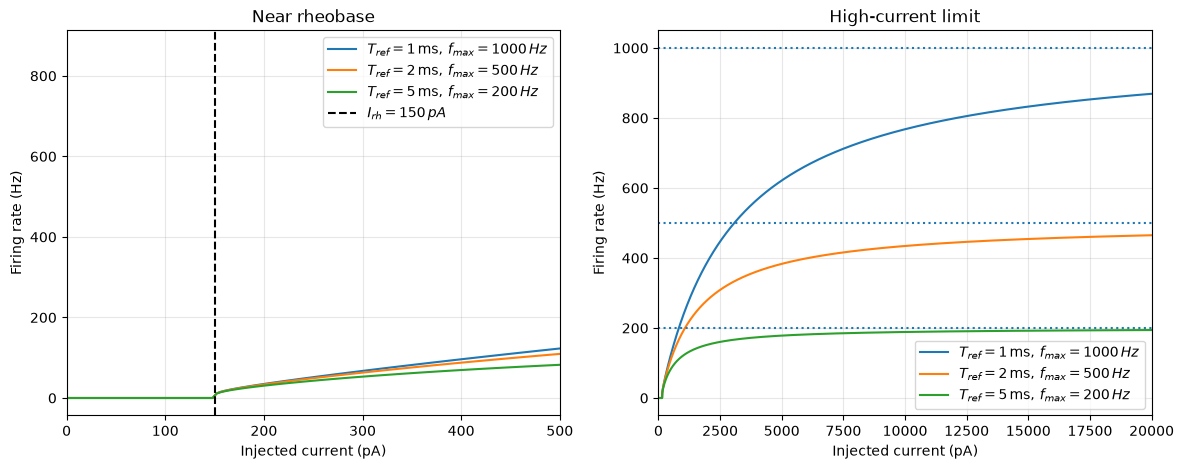

In [ ]:
refractory_periods = np.array([1, 2, 5]) * 1e-3
i = np.linspace(0, 20000, 5000) * 1e-12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for t_refractory in refractory_periods:
    frequency, I_rh = analytical_firing_rate(
        i = i,
        t_refractory = t_refractory,
        v_threshold = -50e-3, 
        v_reset = -65e-3, 
        e_l = -65e-3, 
        r_m = 100e6, 
        c_m = 200 * 1e-12
        )
    fmax = 1/t_refractory
    label = (fr'$T_{{ref}}={t_refractory * 1e3:.0f}\,\mathrm{{ms}},\, f_{{max}} = {fmax:.0f} \, Hz$')
    
    axes[0].plot(i * 1e12, frequency, label = label)
    axes[1].plot(i * 1e12, frequency, label = label)
    axes[1].axhline(fmax, linestyle = ':')

axes[0].axvline(
    I_rh * 1e12,
    color='black',
    linestyle='--',
    label = fr'$I_{{rh}} = {I_rh * 1e12:.0f} \, {{pA}}$'    
)

axes[0].set_xlim(0, 500)
axes[0].set_title('Near rheobase')
axes[1].set_xlim(0, 20000)
axes[1].set_title('High-current limit')

for ax in axes:
    ax.set_xlabel('Injected current (pA)')
    ax.set_ylabel('Firing rate (Hz)')
    ax.grid(alpha = 0.3)
    ax.legend()


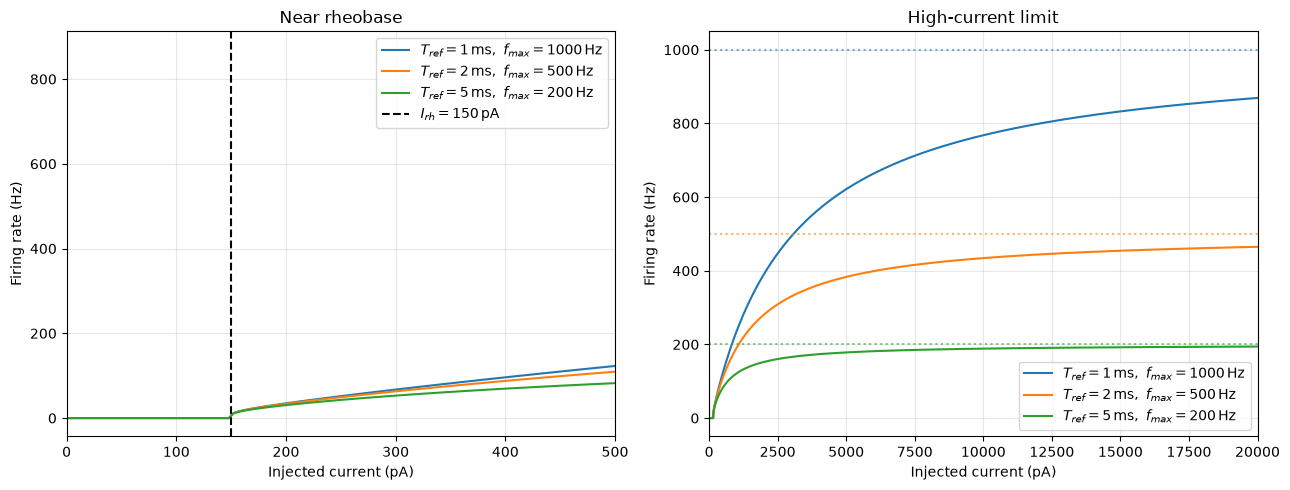

In [89]:
refractory_periods = np.array([1, 2, 5]) * 1e-3
i = np.linspace(0, 20000, 5000) * 1e-12

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for t_refractory in refractory_periods:
    frequency, i_rh = analytical_firing_rate(
        i=i,
        t_refractory=t_refractory,
        v_threshold=-50e-3,
        v_reset=-65e-3,
        e_l=-65e-3,
        r_m=100e6,
        c_m=200e-12
    )

    f_max = 1 / t_refractory

    label = (
        fr'$T_{{ref}}={t_refractory * 1e3:.0f}\,\mathrm{{ms}},\ '
        fr'f_{{max}}={f_max:.0f}\,\mathrm{{Hz}}$'
    )

    axes[0].plot(i * 1e12, frequency, label=label)

    line, = axes[1].plot(i * 1e12, frequency, label=label)
    axes[1].axhline(
        f_max,
        color=line.get_color(),
        linestyle=':',
        alpha=0.6
    )

axes[0].axvline(
    i_rh * 1e12,
    color='black',
    linestyle='--',
    label=fr'$I_{{rh}}={i_rh * 1e12:.0f}\,\mathrm{{pA}}$'
)

axes[0].set_xlim(0, 500)
axes[0].set_title('Near rheobase')

axes[1].set_xlim(0, 20000)
axes[1].set_title('High-current limit')

for ax in axes:
    ax.set_xlabel('Injected current (pA)')
    ax.set_ylabel('Firing rate (Hz)')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()